# Via Rail — Québec City–Windsor Corridor: Exploratory Data Analysis

This notebook performs EDA on the cleaned Via Rail dataset, focusing exclusively on trains and stops within the **Québec City–Windsor corridor** — Canada's busiest intercity passenger rail corridor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ── Load the master Parquet dataset ──────────────────────────────────────────
PARQUET_PATH = '/workspaces/via_rail/clean_data/via_rail_clean.parquet'

df = pd.read_parquet(PARQUET_PATH)

# Parse date columns just in case they come in as objects
for col in ['scrape_date_est', 'service_date']:
    if df[col].dtype == object:
        df[col] = pd.to_datetime(df[col]).dt.date

print(f"Total rows : {len(df):,}")
print(f"Columns    : {df.columns.tolist()}")
print(f"Date range : {df['service_date'].min()}  →  {df['service_date'].max()}")
df.head()

Total rows : 265,697
Columns    : ['scrape_date_est', 'train_key', 'train_number', 'service_date', 'origin', 'destination', 'departed', 'arrived', 'stop_sequence', 'station_name', 'station_code', 'scheduled_arrival_utc', 'estimated_arrival_utc', 'scheduled_departure_utc', 'estimated_departure_utc', 'delay_minutes', 'diff_status', 'is_on_time', 'is_late_15', 'is_late_60', 'is_corridor']
Date range : 2025-03-30  →  2026-05-10


,scrape_date_est,train_key,train_number,service_date,origin,destination,departed,arrived,stop_sequence,station_name,...,scheduled_arrival_utc,estimated_arrival_utc,scheduled_departure_utc,estimated_departure_utc,delay_minutes,diff_status,is_on_time,is_late_15,is_late_60,is_corridor
0,2025-04-01,1 (03-30),1,2025-03-30,TORONTO,VANCOUVER,True,False,0,Toronto,...,NaT,NaT,2025-03-30 13:55:00+00:00,2025-03-31 05:30:00+00:00,935,bad,False,True,True,True
1,2025-04-01,1 (03-30),1,2025-03-30,TORONTO,VANCOUVER,True,False,1,Washago,...,2025-03-30 16:25:00+00:00,2025-03-31 10:24:14+00:00,2025-03-30 16:25:02+00:00,2025-03-31 10:24:14+00:00,1079,bad,False,True,True,False
2,2025-04-01,1 (03-30),1,2025-03-30,TORONTO,VANCOUVER,True,False,2,South Parry,...,2025-03-30 18:27:00+00:00,2025-03-31 12:26:14+00:00,2025-03-30 18:27:02+00:00,2025-03-31 12:26:14+00:00,1079,bad,False,True,True,False
3,2025-04-01,1 (03-30),1,2025-03-30,TORONTO,VANCOUVER,True,False,3,Sudbury (Jct.),...,2025-03-30 20:57:00+00:00,2025-03-31 14:56:14+00:00,2025-03-30 20:57:02+00:00,2025-03-31 14:56:14+00:00,1079,bad,False,True,True,False
4,2025-04-01,1 (03-30),1,2025-03-30,TORONTO,VANCOUVER,True,False,4,Capreol,...,2025-03-30 21:22:00+00:00,2025-03-31 15:21:14+00:00,2025-03-30 21:52:00+00:00,2025-03-31 15:21:14+00:00,1079,bad,False,True,True,False


In [3]:
print("── Data types ──────────────────")
print(df.dtypes)
print()
print("── Null counts ─────────────────")
print(df.isnull().sum())

── Data types ──────────────────
scrape_date_est                         object
train_key                                  str
train_number                               str
service_date                            object
origin                                     str
destination                                str
departed                                  bool
arrived                                   bool
stop_sequence                            Int32
station_name                               str
station_code                               str
scheduled_arrival_utc      datetime64[us, UTC]
estimated_arrival_utc      datetime64[us, UTC]
scheduled_departure_utc    datetime64[us, UTC]
estimated_departure_utc    datetime64[us, UTC]
delay_minutes                            Int32
diff_status                                str
is_on_time                              object
is_late_15                              object
is_late_60                              object
is_corridor                

In [4]:
# ── Corridor station codes (from project spec) ────────────────────────────────
CORRIDOR_STATION_CODES = {
    'WDON', 'CHAT', 'GLNC', 'LNDN', 'INGR', 'WDST', 'BRTF', 'ALDR',
    'OAKV', 'TRTO', 'GUIL', 'OSHA', 'CBRG', 'PHOP', 'TRNJ', 'BLVL',
    'NAPN', 'KGON', 'GANA', 'BRKV', 'CWLL', 'ALEX', 'CSLM', 'OTTW',
    'FALL', 'SMTF', 'SLAM', 'MTRL', 'DORV', 'COTO', 'SHYA', 'DRMV',
    'SFOY', 'QBEC', 'CHNY',
}

# Use the pre-computed is_corridor flag where available; fall back to station code lookup
if 'is_corridor' in df.columns:
    corr = df[df['is_corridor'] == True].copy()
else:
    corr = df[df['station_code'].isin(CORRIDOR_STATION_CODES)].copy()

# Identify corridor TRAINS: trains that have at least one corridor stop
corridor_trains = corr['train_number'].unique()
print(f"Unique corridor train numbers : {len(corridor_trains)}")
print(f"Corridor stop rows            : {len(corr):,}  ({100*len(corr)/len(df):.1f}% of total)")
print()
print("Corridor train numbers:", sorted(corridor_trains, key=lambda x: int(x) if x.isdigit() else x))

Unique corridor train numbers : 74
Corridor stop rows            : 120,862  (45.5% of total)

Corridor train numbers: ['1', '2', '14', '15', '20', '22', '24', '26', '28', '29', '31', '33', '35', '37', '38', '39', '40', '41', '43', '44', '45', '46', '47', '48', '50', '52', '53', '54', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '75', '76', '78', '79', '82', '83', '84', '87', '97', '98', '600', '601', '602', '603', '604', '606', '607', '622', '624', '633', '636', '637', '641', '643', '644', '645', '646', '647', '668', '669', '684']


In [5]:
# Routes found in the corridor subset
route_counts = (
    corr.groupby(['origin', 'destination'])['train_number']
    .nunique()
    .reset_index()
    .rename(columns={'train_number': 'unique_trains'})
    .sort_values('unique_trains', ascending=False)
)
print("Routes in the corridor:")
print(route_counts.to_string(index=False))

Routes in the corridor:
          origin   destination  unique_trains
          OTTAWA       TORONTO             10
         TORONTO        OTTAWA              9
         TORONTO      MONTRÉAL              6
        MONTRÉAL       TORONTO              6
          QUÉBEC        OTTAWA              5
          OTTAWA        QUÉBEC              5
         WINDSOR       TORONTO              4
         TORONTO       WINDSOR              4
        MONTRÉAL        OTTAWA              4
        MONTRÉAL        QUÉBEC              3
         TORONTO        LONDON              2
          OTTAWA      MONTRÉAL              2
      SENNETERRE      MONTRÉAL              2
         WINDSOR          MIMC              2
        MONTRÉAL    SENNETERRE              2
       JONQUIÈRE      MONTRÉAL              2
          HERVEY      MONTRÉAL              2
        CHAMBORD      MONTRÉAL              1
         HALIFAX      MONTRÉAL              1
   NIAGARA FALLS       TORONTO              1
          

In [6]:
# ── 4. Summary Statistics ─────────────────────────────────────────────────────

# Numeric summary (delay_minutes, stop_sequence)
print("=== Descriptive statistics (corridor stops) ===")
print(corr[['delay_minutes', 'stop_sequence']].describe().round(2))
print()

# Missing values in the corridor subset
missing = corr.isnull().sum()
missing_pct = (missing / len(corr) * 100).round(2)
missing_df = pd.DataFrame({'null_count': missing, 'null_pct': missing_pct})
print("=== Missing values ===")
print(missing_df[missing_df['null_count'] > 0])
print()

# Duplicate check (same train + service_date + station_code + scrape_date should be unique)
dupes = corr.duplicated(subset=['train_number', 'service_date', 'station_code', 'scrape_date_est']).sum()
print(f"Duplicate rows (train+date+station+scrape): {dupes:,}")

=== Descriptive statistics (corridor stops) ===
       delay_minutes  stop_sequence
count        67214.0       120862.0
mean           21.68           4.18
std             38.3           4.24
min           -143.0            0.0
25%              0.0            1.0
50%             10.0            3.0
75%             28.0            6.0
max            935.0           66.0

=== Missing values ===
                         null_count  null_pct
scheduled_arrival_utc         16314     13.50
estimated_arrival_utc         61640     51.00
scheduled_departure_utc       12791     10.58
estimated_departure_utc       61478     50.87
delay_minutes                 53648     44.39
diff_status                   53648     44.39
is_on_time                    53648     44.39
is_late_15                    53648     44.39
is_late_60                    53648     44.39

Duplicate rows (train+date+station+scrape): 0


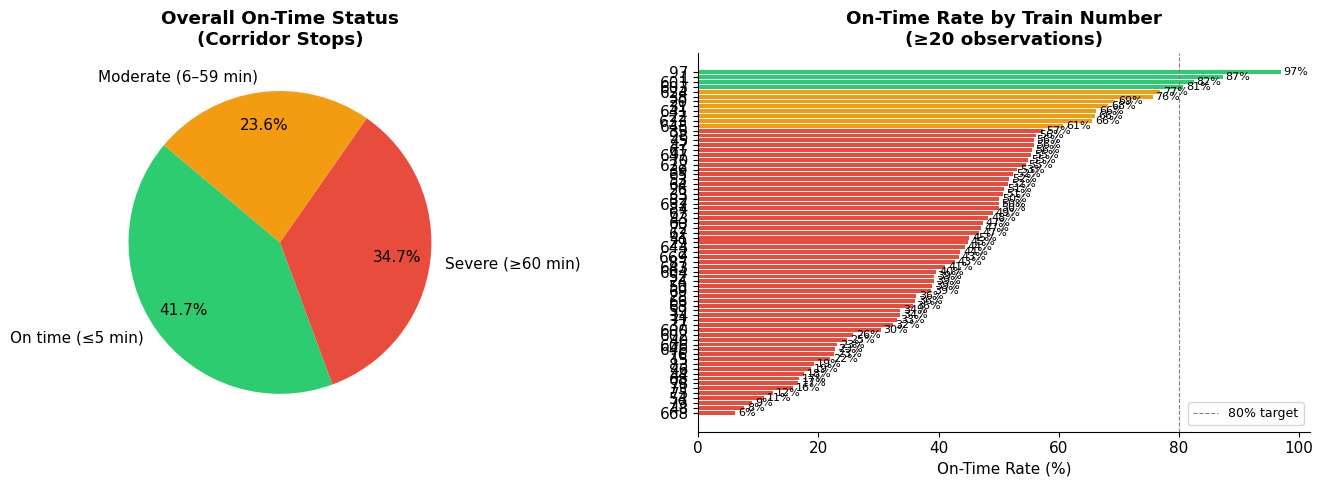


Overall on-time rate (≤5 min): 40.8%
Moderate late rate (6–59 min):  23.6%
Severely late rate (≥60 min):   34.7%


In [7]:
# ── 5. On-Time Performance Analysis ──────────────────────────────────────────

# Only include rows where diff_status is known (train has departed)
perf = corr[corr['diff_status'].notna()].copy()

# ── 5a. Overall on-time rate ──────────────────────────────────────────────────
status_counts = perf['diff_status'].value_counts()
status_labels = {'goo': 'On time (≤5 min)', 'med': 'Moderate (6–59 min)', 'bad': 'Severe (≥60 min)'}
status_colors = {'goo': '#2ecc71', 'med': '#f39c12', 'bad': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = [status_labels.get(k, k) for k in status_counts.index]
colors = [status_colors.get(k, '#999') for k in status_counts.index]
axes[0].pie(status_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.78)
axes[0].set_title('Overall On-Time Status\n(Corridor Stops)', fontweight='bold')

# ── 5b. On-time rate by train number ─────────────────────────────────────────
otp_by_train = (
    perf.groupby('train_number')['is_on_time']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'otp_rate', 'count': 'n_stops'})
    .reset_index()
    .query('n_stops >= 20')          # filter out trains with very few observations
    .sort_values('otp_rate', ascending=True)
)

bars = axes[1].barh(
    otp_by_train['train_number'],
    otp_by_train['otp_rate'] * 100,
    color=[('#2ecc71' if r >= 0.8 else '#f39c12' if r >= 0.6 else '#e74c3c')
           for r in otp_by_train['otp_rate']]
)
axes[1].axvline(80, color='grey', linestyle='--', linewidth=0.8, label='80% target')
axes[1].set_xlabel('On-Time Rate (%)')
axes[1].set_title('On-Time Rate by Train Number\n(≥20 observations)', fontweight='bold')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, otp_by_train['otp_rate'] * 100):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nOverall on-time rate (≤5 min): {perf['is_on_time'].mean()*100:.1f}%")
print(f"Moderate late rate (6–59 min):  {(perf['diff_status']=='med').mean()*100:.1f}%")
print(f"Severely late rate (≥60 min):   {(perf['diff_status']=='bad').mean()*100:.1f}%")

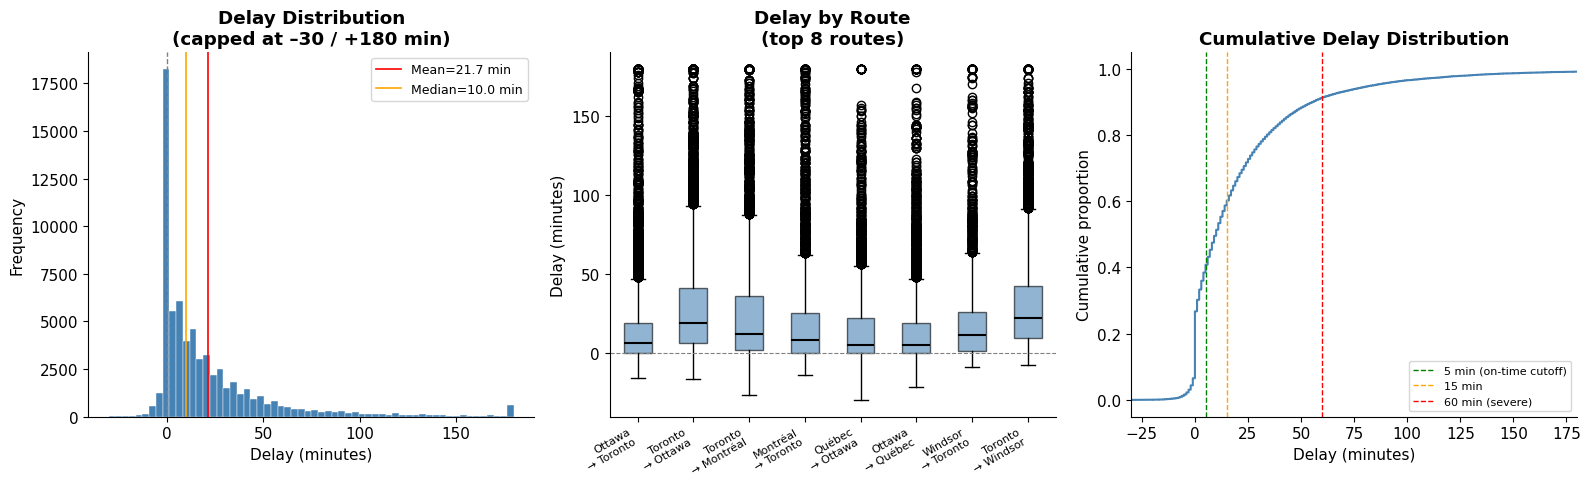

Delay stats (all corridor stops):
  Mean  μ  = 21.7 min
  Std   σ  = 38.3 min
  Median   = 10.0 min
  P90      = 56.0 min
  P95      = 84.0 min
  P99      = 171.0 min


In [8]:
# ── 6. Delay Distribution Analysis ───────────────────────────────────────────

# Cap extreme outliers for display (keep for stats)
delay = corr['delay_minutes'].dropna()
delay_cap = delay.clip(-30, 180)   # cap at ±3 hr for display

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(delay_cap, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='grey', linewidth=1, linestyle='--')
axes[0].axvline(delay.mean(), color='red', linewidth=1.2, linestyle='-', label=f'Mean={delay.mean():.1f} min')
axes[0].axvline(delay.median(), color='orange', linewidth=1.2, linestyle='-', label=f'Median={delay.median():.1f} min')
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Delay Distribution\n(capped at –30 / +180 min)', fontweight='bold')
axes[0].legend(fontsize=9)

# Box plot by route (origin → destination)
corr_route = corr.copy()
corr_route['route'] = corr_route['origin'].str.title() + ' → ' + corr_route['destination'].str.title()
top_routes = corr_route['route'].value_counts().head(8).index
box_data = [corr_route.loc[corr_route['route'] == r, 'delay_minutes'].clip(-30, 180).dropna().values
            for r in top_routes]
bp = axes[1].boxplot(box_data, vert=True, patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[1].set_xticklabels([r.replace(' → ', '\n→ ') for r in top_routes], fontsize=8, rotation=30, ha='right')
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Delay (minutes)')
axes[1].set_title('Delay by Route\n(top 8 routes)', fontweight='bold')

# Cumulative distribution
sorted_delay = np.sort(delay.values)
cdf = np.arange(1, len(sorted_delay) + 1) / len(sorted_delay)
axes[2].plot(sorted_delay.clip(-30, 240), cdf, color='steelblue', linewidth=1.5)
axes[2].axvline(5, color='green',  linestyle='--', linewidth=1, label='5 min (on-time cutoff)')
axes[2].axvline(15, color='orange', linestyle='--', linewidth=1, label='15 min')
axes[2].axvline(60, color='red',    linestyle='--', linewidth=1, label='60 min (severe)')
axes[2].set_xlabel('Delay (minutes)')
axes[2].set_ylabel('Cumulative proportion')
axes[2].set_title('Cumulative Delay Distribution', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].set_xlim(-30, 180)

plt.tight_layout()
plt.show()

print(f"Delay stats (all corridor stops):")
print(f"  Mean  μ  = {delay.mean():.1f} min")
print(f"  Std   σ  = {delay.std():.1f} min")
print(f"  Median   = {delay.median():.1f} min")
print(f"  P90      = {delay.quantile(0.90):.1f} min")
print(f"  P95      = {delay.quantile(0.95):.1f} min")
print(f"  P99      = {delay.quantile(0.99):.1f} min")

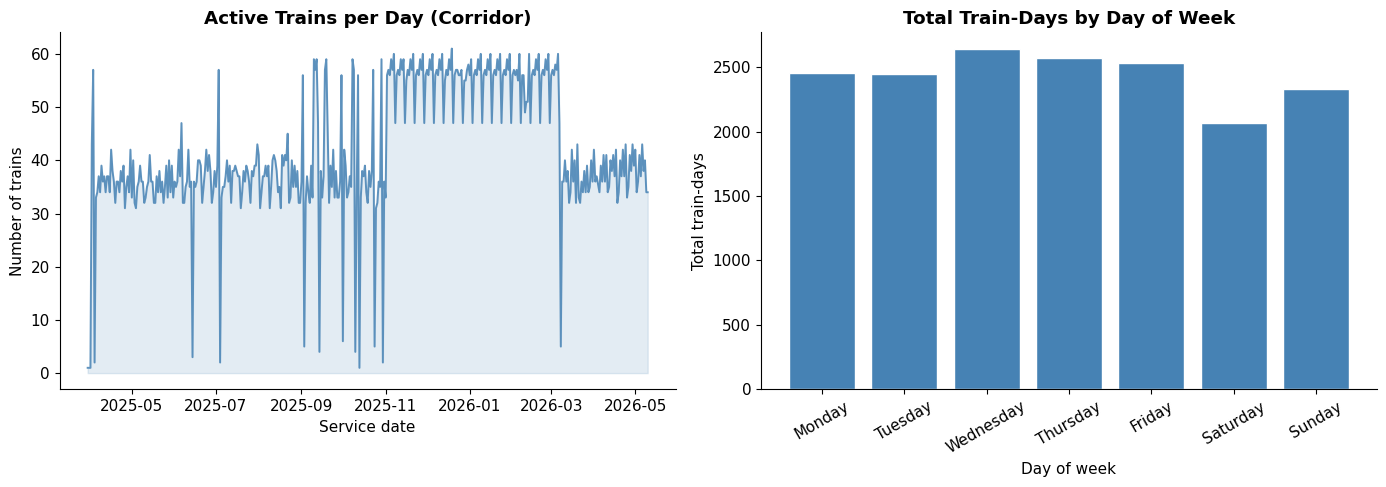

Top 15 most frequent corridor trains:
train_number  service_days  pct_days
          24           391      96.8
          71           391      96.8
          64           391      96.8
          65           391      96.8
          63           391      96.8
          47           391      96.8
          52           391      96.8
          40           391      96.8
          35           391      96.8
          37           391      96.8
          67           391      96.8
          70           391      96.8
          76           391      96.8
          72           391      96.8
          97           390      96.5


In [9]:
# ── 7. Service Frequency & Train Activity ────────────────────────────────────
# (The Via Rail dataset does not contain ridership/occupancy fields.
#  This section instead analyses service frequency — how many unique train
#  trips operated per day — as a proxy for service volume.)

from collections import Counter

# One row per unique (train_number, service_date) in the corridor
trips = (
    corr.drop_duplicates(subset=['train_number', 'service_date'])
    .copy()
)
trips['service_date'] = pd.to_datetime(trips['service_date'])
trips['dow'] = trips['service_date'].dt.day_name()
trips['month'] = trips['service_date'].dt.to_period('M').astype(str)

# ── 7a. Trips per service date ────────────────────────────────────────────────
trips_per_day = trips.groupby('service_date').size().reset_index(name='n_trains')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(trips_per_day['service_date'], trips_per_day['n_trains'],
             color='steelblue', linewidth=1.4, alpha=0.85)
axes[0].fill_between(trips_per_day['service_date'], trips_per_day['n_trains'],
                     alpha=0.15, color='steelblue')
axes[0].set_title('Active Trains per Day (Corridor)', fontweight='bold')
axes[0].set_xlabel('Service date')
axes[0].set_ylabel('Number of trains')

# ── 7b. Avg trips by day of week ─────────────────────────────────────────────
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_dow = (
    trips.groupby('dow')['train_number']
    .count()
    .reindex(DOW_ORDER)
    .reset_index()
)
by_dow.columns = ['dow', 'n_trips']
axes[1].bar(by_dow['dow'], by_dow['n_trips'], color='steelblue', edgecolor='white')
axes[1].set_title('Total Train-Days by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Total train-days')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── 7c. Most frequent trains ──────────────────────────────────────────────────
top_trains = (
    trips.groupby('train_number')['service_date']
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={'service_date': 'service_days'})
)
total_days = trips['service_date'].nunique()
top_trains['pct_days'] = (top_trains['service_days'] / total_days * 100).round(1)
print("Top 15 most frequent corridor trains:")
print(top_trains.to_string(index=False))

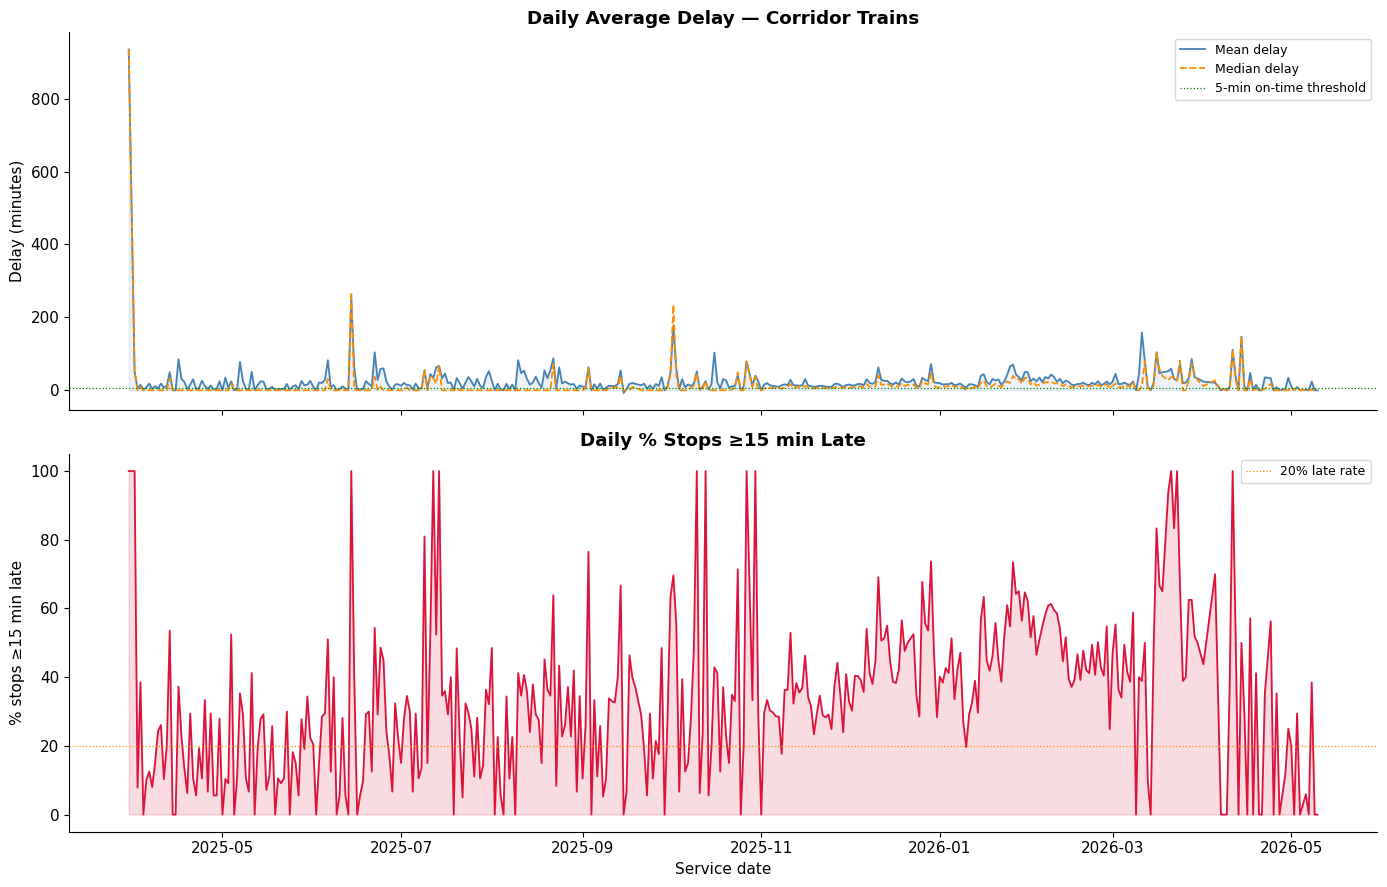

TypeError: Image data of dtype object cannot be converted to float

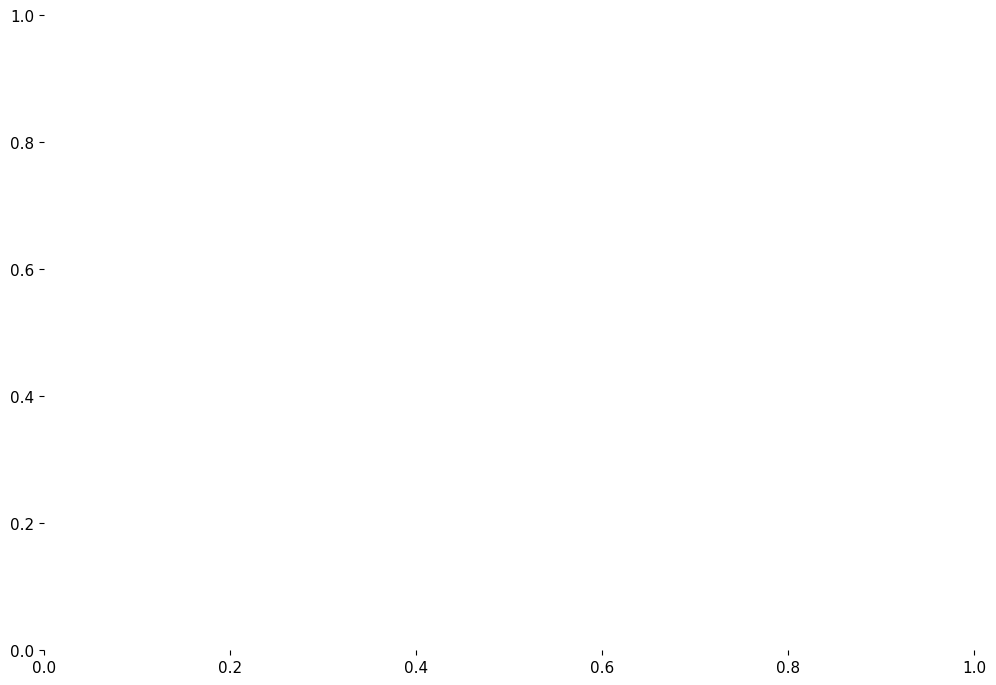

In [10]:
# ── 8. Time Series Analysis ───────────────────────────────────────────────────

corr_ts = corr.copy()
corr_ts['service_date'] = pd.to_datetime(corr_ts['service_date'])

# ── 8a. Daily avg delay over time ─────────────────────────────────────────────
daily_delay = (
    corr_ts[corr_ts['delay_minutes'].notna()]
    .groupby('service_date')['delay_minutes']
    .agg(['mean', 'median', lambda x: (x >= 15).mean() * 100])
    .reset_index()
)
daily_delay.columns = ['service_date', 'mean_delay', 'median_delay', 'pct_late_15']

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(daily_delay['service_date'], daily_delay['mean_delay'],
             label='Mean delay', color='steelblue', linewidth=1.3)
axes[0].plot(daily_delay['service_date'], daily_delay['median_delay'],
             label='Median delay', color='darkorange', linewidth=1.3, linestyle='--')
axes[0].axhline(5, color='green', linestyle=':', linewidth=0.9, label='5-min on-time threshold')
axes[0].fill_between(daily_delay['service_date'], daily_delay['mean_delay'], alpha=0.1, color='steelblue')
axes[0].set_ylabel('Delay (minutes)')
axes[0].set_title('Daily Average Delay — Corridor Trains', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(daily_delay['service_date'], daily_delay['pct_late_15'],
             color='crimson', linewidth=1.3)
axes[1].fill_between(daily_delay['service_date'], daily_delay['pct_late_15'], alpha=0.15, color='crimson')
axes[1].axhline(20, color='darkorange', linestyle=':', linewidth=0.9, label='20% late rate')
axes[1].set_ylabel('% stops ≥15 min late')
axes[1].set_xlabel('Service date')
axes[1].set_title('Daily % Stops ≥15 min Late', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── 8b. Day-of-week heatmap ────────────────────────────────────────────────────
corr_ts['dow']   = corr_ts['service_date'].dt.day_name()
corr_ts['month'] = corr_ts['service_date'].dt.to_period('M').astype(str)

dow_month_otp = (
    corr_ts[corr_ts['delay_minutes'].notna()]
    .groupby(['month', 'dow'])['is_on_time']
    .mean()
    .unstack('dow')
    .reindex(columns=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
    * 100
)

fig, ax = plt.subplots(figsize=(12, max(4, len(dow_month_otp) * 0.55)))
sns.heatmap(dow_month_otp, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=50, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'On-time rate (%)'})
ax.set_title('On-Time Rate (%) by Month × Day of Week', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

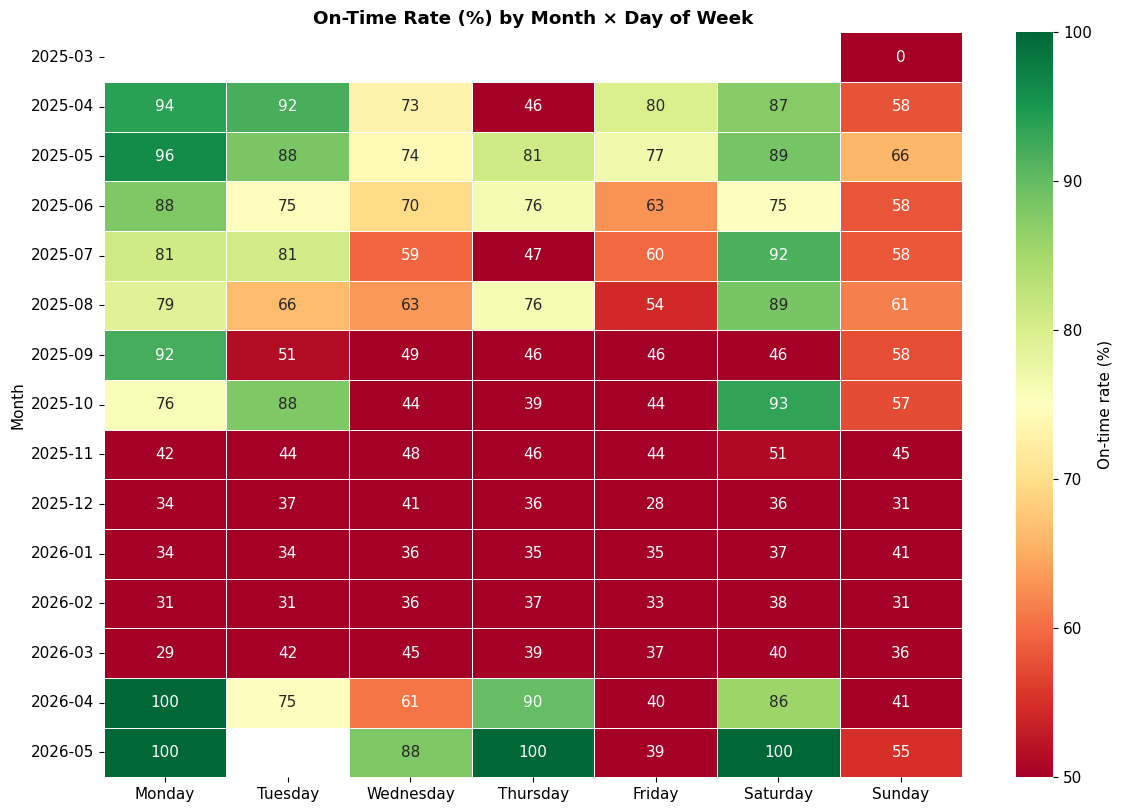

In [11]:
# ── 8b (fixed). On-time rate heatmap: Month × Day of Week ────────────────────
corr_ts2 = corr.copy()
corr_ts2['service_date'] = pd.to_datetime(corr_ts2['service_date'])
corr_ts2['dow']   = corr_ts2['service_date'].dt.day_name()
corr_ts2['month'] = corr_ts2['service_date'].dt.to_period('M').astype(str)

# Keep only rows with a known is_on_time and coerce bool→float explicitly
otp_rows = corr_ts2[corr_ts2['is_on_time'].notna()].copy()
otp_rows['on_time_f'] = otp_rows['is_on_time'].astype(float)

dow_month_otp = (
    otp_rows
    .groupby(['month', 'dow'])['on_time_f']
    .mean()
    .unstack('dow')
    .reindex(columns=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
    .multiply(100)
    .astype('float64')
)

fig, ax = plt.subplots(figsize=(12, max(4, len(dow_month_otp) * 0.55)))
sns.heatmap(dow_month_otp, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=50, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'On-time rate (%)'})
ax.set_title('On-Time Rate (%) by Month × Day of Week', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

Station performance (top 10 worst avg delay):
station_name  n_obs  mean_delay  otp_rate late15_rate
     Glencoe    866   32.221709  0.086605    0.584296
     Chatham   1187   31.496209  0.385847    0.557709
     Windsor   1266   29.416272  0.399684    0.557662
     Napanee    508   28.588583  0.228346    0.509843
   Port Hope    464   28.431034  0.137931    0.590517
Trenton Jct.    647   28.026275  0.132921    0.561051
   Ingersoll    850   27.048235  0.184706    0.530588
Smiths Falls   1269   26.030733  0.420016    0.446809
   Woodstock   1204   25.856312  0.198505     0.54485
   Brantford   1340    25.03806  0.158209    0.534328


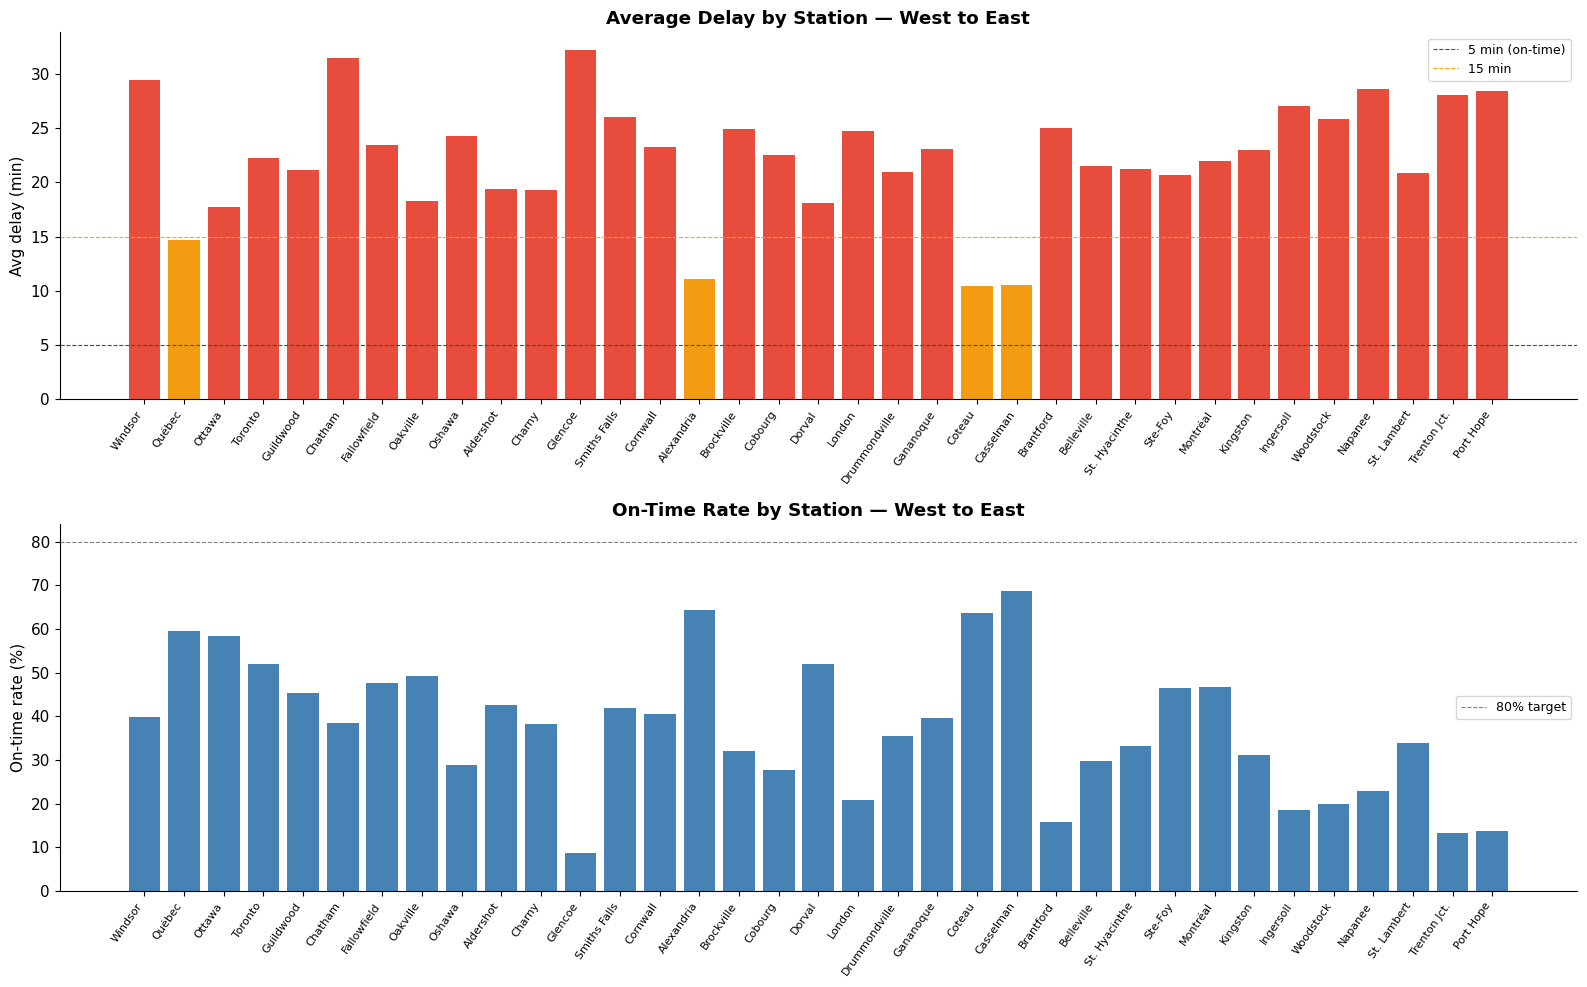

TypeError: Image data of dtype object cannot be converted to float

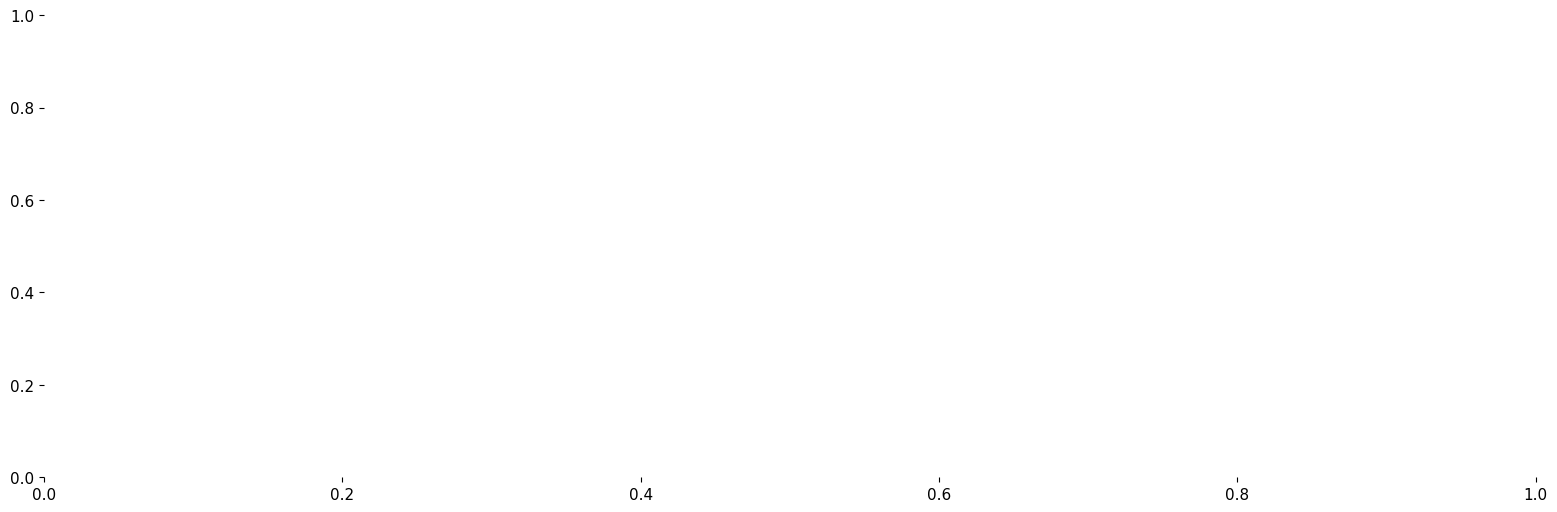

In [12]:
# ── 9. Route and Station Analysis ─────────────────────────────────────────────

# Station-level metrics: avg delay, on-time rate, pct late ≥15 min
station_stats = (
    corr[corr['delay_minutes'].notna()]
    .groupby(['station_code', 'station_name'])
    .agg(
        n_obs        = ('delay_minutes', 'count'),
        mean_delay   = ('delay_minutes', 'mean'),
        median_delay = ('delay_minutes', 'median'),
        otp_rate     = ('is_on_time', 'mean'),
        late15_rate  = ('is_late_15', 'mean'),
    )
    .reset_index()
    .query('n_obs >= 20')
    .sort_values('mean_delay', ascending=False)
)

print("Station performance (top 10 worst avg delay):")
print(station_stats.head(10)[['station_name', 'n_obs', 'mean_delay', 'otp_rate', 'late15_rate']].to_string(index=False))

# ── 9a. Mean delay by station (sorted west→east using stop_sequence proxy) ────
station_seq = (
    corr.groupby('station_code')['stop_sequence'].median().reset_index()
    .rename(columns={'stop_sequence': 'median_seq'})
)
station_plot = station_stats.merge(station_seq, on='station_code').sort_values('median_seq')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Mean delay bar
colors = ['#e74c3c' if d > 15 else '#f39c12' if d > 5 else '#2ecc71'
          for d in station_plot['mean_delay']]
axes[0].bar(station_plot['station_name'], station_plot['mean_delay'], color=colors)
axes[0].axhline(5,  color='green',  linestyle='--', linewidth=0.8, label='5 min (on-time)')
axes[0].axhline(15, color='orange', linestyle='--', linewidth=0.8, label='15 min')
axes[0].set_xticks(range(len(station_plot)))
axes[0].set_xticklabels(station_plot['station_name'], rotation=55, ha='right', fontsize=8)
axes[0].set_ylabel('Avg delay (min)')
axes[0].set_title('Average Delay by Station — West to East', fontweight='bold')
axes[0].legend(fontsize=9)

# On-time rate bar
axes[1].bar(station_plot['station_name'], station_plot['otp_rate'] * 100, color='steelblue')
axes[1].axhline(80, color='grey', linestyle='--', linewidth=0.8, label='80% target')
axes[1].set_xticks(range(len(station_plot)))
axes[1].set_xticklabels(station_plot['station_name'], rotation=55, ha='right', fontsize=8)
axes[1].set_ylabel('On-time rate (%)')
axes[1].set_title('On-Time Rate by Station — West to East', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── 9b. Heatmap: on-time rate per train × station ─────────────────────────────
pivot_data = (
    corr[corr['delay_minutes'].notna()]
    .merge(station_seq, on='station_code')
    .sort_values('median_seq')
)

# Keep top 12 trains (most observed)
top12_trains = (
    pivot_data.groupby('train_number')['delay_minutes'].count()
    .sort_values(ascending=False).head(12).index
)
pivot = (
    pivot_data[pivot_data['train_number'].isin(top12_trains)]
    .groupby(['train_number', 'station_name'])['is_on_time']
    .mean()
    .unstack('station_name')
    * 100
)
# Order columns by median stop sequence
col_order = (
    pivot_data[pivot_data['station_name'].isin(pivot.columns)]
    .groupby('station_name')['median_seq'].median()
    .sort_values().index
)
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(max(14, len(pivot.columns) * 0.55), 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=40, vmax=100, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'On-time rate (%)'})
ax.set_title('On-Time Rate (%) by Train × Station\n(top 12 trains by observation count)', fontweight='bold')
ax.set_xlabel('Station (West → East)')
ax.set_ylabel('Train number')
ax.tick_params(axis='x', rotation=50, labelsize=8)
plt.tight_layout()
plt.show()

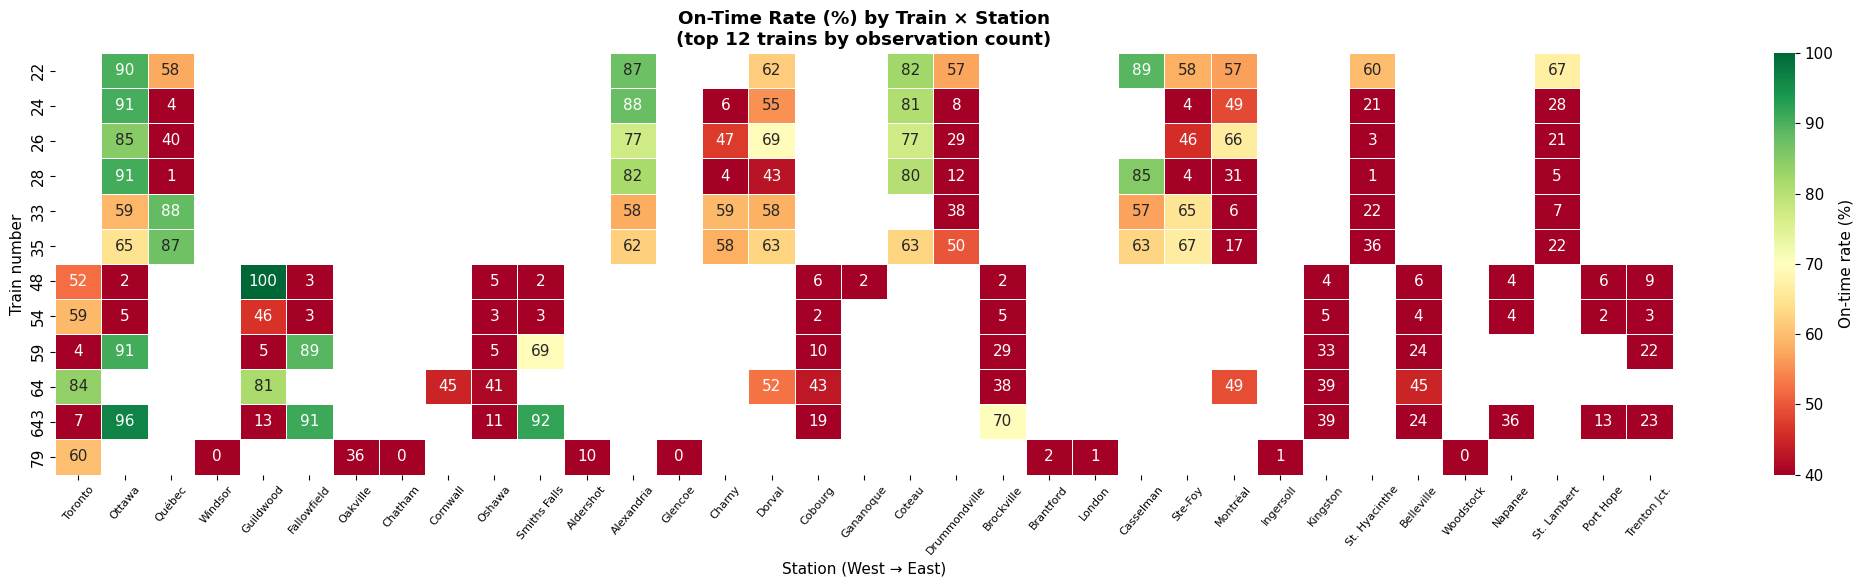

In [13]:
# ── 9b (fixed). On-time rate heatmap: Train × Station ────────────────────────
station_seq2 = (
    corr.groupby('station_code')['stop_sequence'].median().reset_index()
    .rename(columns={'stop_sequence': 'median_seq'})
)
pivot_data2 = (
    corr[corr['is_on_time'].notna()]
    .assign(on_time_f=lambda x: x['is_on_time'].astype(float))
    .merge(station_seq2, on='station_code')
    .sort_values('median_seq')
)

top12_trains = (
    pivot_data2.groupby('train_number')['on_time_f'].count()
    .sort_values(ascending=False).head(12).index
)
pivot2 = (
    pivot_data2[pivot_data2['train_number'].isin(top12_trains)]
    .groupby(['train_number', 'station_name'])['on_time_f']
    .mean()
    .unstack('station_name')
    .multiply(100)
    .astype('float64')
)

# Order columns west → east
col_order2 = (
    pivot_data2[pivot_data2['station_name'].isin(pivot2.columns)]
    .groupby('station_name')['median_seq'].median()
    .sort_values().index
)
pivot2 = pivot2.reindex(columns=[c for c in col_order2 if c in pivot2.columns])

fig, ax = plt.subplots(figsize=(max(14, len(pivot2.columns) * 0.6), 6))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=40, vmax=100, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'On-time rate (%)'})
ax.set_title('On-Time Rate (%) by Train × Station\n(top 12 trains by observation count)', fontweight='bold')
ax.set_xlabel('Station (West → East)')
ax.set_ylabel('Train number')
ax.tick_params(axis='x', rotation=50, labelsize=8)
plt.tight_layout()
plt.show()